In [25]:
import torch
from torch import nn
from dataset import Rice2
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torch.utils.data import Subset

from utility import plot_samples_gan, plot_losses, to_img, plot_test_samples
from losses import weighted_l1_loss, compute_ssim
from models import UNet, Discriminator

import time
import os

import numpy as np

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
import subprocess
import torch


def pick_freest_gpu():
    """Gibt den Index der GPU mit dem meisten freien Speicher zurück."""
    if not torch.cuda.is_available():
        return None
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.free", "--format=csv,nounits,noheader"]
        ).decode()
        free = [int(x) for x in out.strip().split("\n")]
        best = max(range(len(free)), key=lambda i: free[i])
        print(f"Freier Speicher pro GPU (MiB): {free} → wähle GPU {best}")
        return best
    except Exception as e:
        print(f"GPU-Abfrage fehlgeschlagen ({e}), nehme GPU 0")
        return 0


gpu = pick_freest_gpu()
device = torch.device(f"cuda:{gpu}" if gpu is not None else "cpu")

Freier Speicher pro GPU (MiB): [36675, 34010, 42487, 42487] → wähle GPU 2


In [27]:
#hyperparameter
num_epochs = 50
batch_size = 8
beta = 50
lr_g = 1e-4
lr_d = 1e-4
use_masks = True          # Maske als zusätzlichen Generator-Input geben
save_last_n_samples = 3   # Sample-Bilder der letzten N Epochen speichern
plot_every = 10         # zusätzlich alle N Epochen ein Sample anzeigen
w_factor = 0.3            # Gewicht des maskierten L1-Terms
w_extra = 4.0             # Wolken-Extragewicht im maskierten L1
best_score = -1.0
best_psnr = -1.0
generator = UNet(in_channels=4, out_channels=3, feature_channels=64, depth=5).to(device)
discriminator = Discriminator(in_channels=6, feature_channels=16).to(device)

optimizer_g = Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
optimizer_d = Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

scheduler_g = None
scheduler_d = None

l1 = nn.L1Loss()
bce = nn.BCEWithLogitsLoss()

train_losses_g, train_losses_d = [], []
val_losses_g, val_losses_d = [], []
val_psnrs, val_ssims = [], []

# data_dir = "/home/christopher/sync/projekte/GNN_projekt/RICE_DATASET/RICE2"
data_dir = "/data/home/lec42675/cloud_removal/RICE_DATASET/RICE2"

# 1) Volles Dataset nur zur Bestimmung der Split-Indizes.
base_dataset = Rice2(data_dir, augment=False)
n_total = len(base_dataset)
 
n_train = int(0.64 * n_total)
n_val = int(0.16 * n_total)
n_test = n_total - n_train - n_val   # Rest, damit die Summe exakt aufgeht
 
# 2) Reproduzierbarer Split (fester Seed -> immer dieselbe Aufteilung).
split_generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(
    base_dataset, [n_train, n_val, n_test], generator=split_generator
)
train_idx = train_subset.indices
val_idx = val_subset.indices
test_idx = test_subset.indices
 
# 3) Getrennte Dataset-Instanzen: Train augmentiert, Val/Test nicht.
train_data = Subset(Rice2(data_dir, augment=True), train_idx)
val_data = Subset(Rice2(data_dir, augment=False), val_idx)
test_data = Subset(Rice2(data_dir, augment=False), test_idx)
 
print(
    f"Gesamt: {n_total} | "
    f"Train: {len(train_data)} ({len(train_data)/n_total:.0%}) | "
    f"Val: {len(val_data)} ({len(val_data)/n_total:.0%}) | "
    f"Test: {len(test_data)} ({len(test_data)/n_total:.0%})"
)
 
# 4) DataLoader.
train_dataloader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True,
    num_workers=4, pin_memory=True, persistent_workers=True,
)
val_dataloader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True,
)
test_dataloader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True,
)
 

Gesamt: 736 | Train: 471 (64%) | Val: 117 (16%) | Test: 148 (20%)


In [28]:
plot_dataset = Rice2(data_dir, augment=False)

# gewünschte Dateinamen (passe die Endung an deine echten Dateien an!)
wanted_names = ["548.png", "449.png", "282.png", "111.png", "22.png"]

cloudy_list, label_list, mask_list = [], [], []
for name in wanted_names:
    pos = plot_dataset.ids.index(name)   # Position dieses Dateinamens finden
    c, l, m = plot_dataset[pos]
    cloudy_list.append(c)
    label_list.append(l)
    mask_list.append(m)

fixed_batch = (torch.stack(cloudy_list), torch.stack(label_list), torch.stack(mask_list))

/data/home/lec42675/.venv/gpu-env/lib/python3.10/site-packages/torchvision/transforms/v2/functional/_deprecated.py:12: UserWarning: The function `to_tensor(...)` is deprecated and will be removed in a future release. Instead, please use `to_image(...)` followed by `to_dtype(..., dtype=torch.float32, scale=True)`.
  warnings.warn(


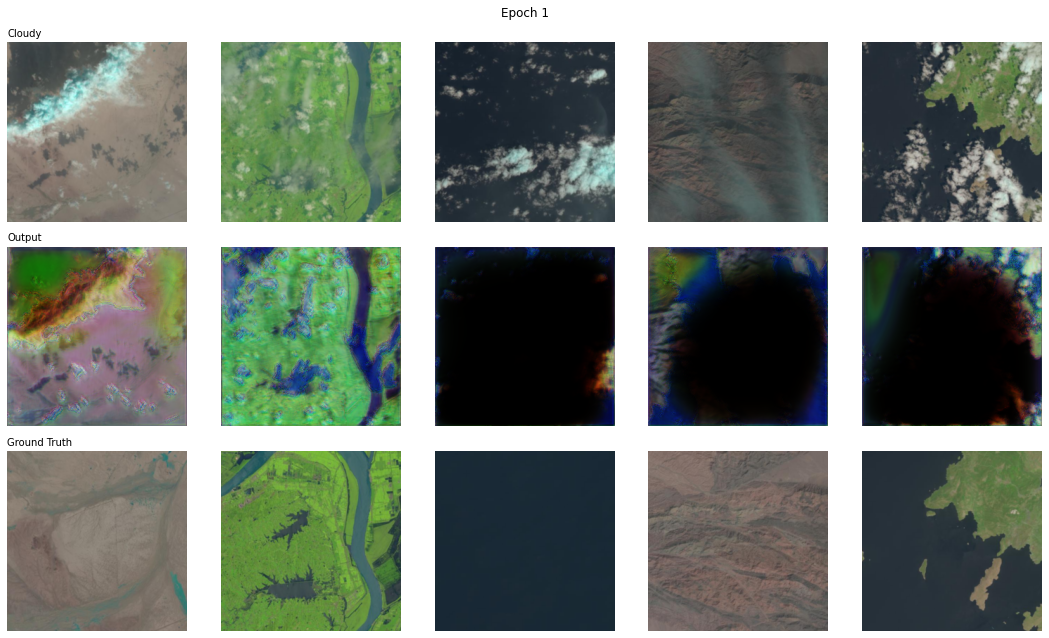

Epoch [1/50] | LR: 1.00e-04 G: 59.03  39.320 | D: 0.66  0.658 | PSNR: 17.36 | SSIM: 0.5127
Epoch [2/50] | LR: 1.00e-04 G: 64.19  70.295 | D: 0.60  0.839 | PSNR: 18.40 | SSIM: 0.5993
Epoch [3/50] | LR: 1.00e-04 G: 66.76  59.715 | D: 0.61  0.850 | PSNR: 20.26 | SSIM: 0.6769
Epoch [4/50] | LR: 1.00e-04 G: 67.87  37.019 | D: 0.62  0.777 | PSNR: 23.53 | SSIM: 0.7387
Epoch [5/50] | LR: 1.00e-04 G: 64.39  60.727 | D: 0.63  0.735 | PSNR: 21.93 | SSIM: 0.7046
Epoch [6/50] | LR: 1.00e-04 G: 66.02  46.531 | D: 0.62  0.815 | PSNR: 22.40 | SSIM: 0.7473
Epoch [7/50] | LR: 1.00e-04 G: 64.74  47.865 | D: 0.62  0.733 | PSNR: 23.36 | SSIM: 0.7578
Epoch [8/50] | LR: 1.00e-04 G: 68.62  42.653 | D: 0.59  0.739 | PSNR: 22.36 | SSIM: 0.7161
Epoch [9/50] | LR: 1.00e-04 G: 73.22  51.294 | D: 0.56  0.774 | PSNR: 24.42 | SSIM: 0.7752
Epoch [10/50] | LR: 1.00e-04 G: 84.26  54.992 | D: 0.50  0.807 | PSNR: 24.08 | SSIM: 0.7714


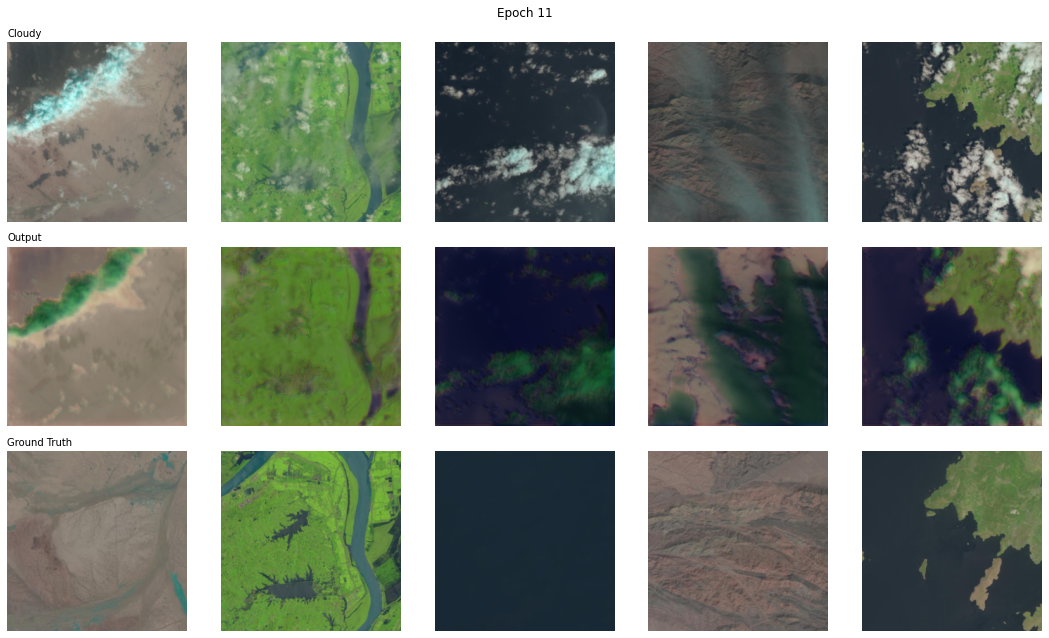

Epoch [11/50] | LR: 1.00e-04 G: 81.19  67.985 | D: 0.55  0.802 | PSNR: 23.83 | SSIM: 0.7700
Epoch [12/50] | LR: 1.00e-04 G: 87.51  49.167 | D: 0.52  1.047 | PSNR: 24.88 | SSIM: 0.7935
Epoch [13/50] | LR: 1.00e-04 G: 81.95  43.184 | D: 0.55  0.721 | PSNR: 24.79 | SSIM: 0.7848
Epoch [14/50] | LR: 1.00e-04 G: 82.92  60.915 | D: 0.54  0.740 | PSNR: 20.19 | SSIM: 0.7228
Epoch [15/50] | LR: 1.00e-04 G: 87.45  57.364 | D: 0.48  0.798 | PSNR: 23.79 | SSIM: 0.7771
Epoch [16/50] | LR: 1.00e-04 G: 93.26  48.147 | D: 0.48  1.043 | PSNR: 22.87 | SSIM: 0.6875
Epoch [17/50] | LR: 1.00e-04 G: 86.58  70.632 | D: 0.55  0.891 | PSNR: 24.82 | SSIM: 0.7985
Epoch [18/50] | LR: 1.00e-04 G: 86.88  70.725 | D: 0.55  0.949 | PSNR: 25.58 | SSIM: 0.7837
Epoch [19/50] | LR: 1.00e-04 G: 88.14  54.207 | D: 0.50  0.712 | PSNR: 23.13 | SSIM: 0.7745
Epoch [20/50] | LR: 1.00e-04 G: 86.12  61.131 | D: 0.52  0.803 | PSNR: 25.49 | SSIM: 0.7996


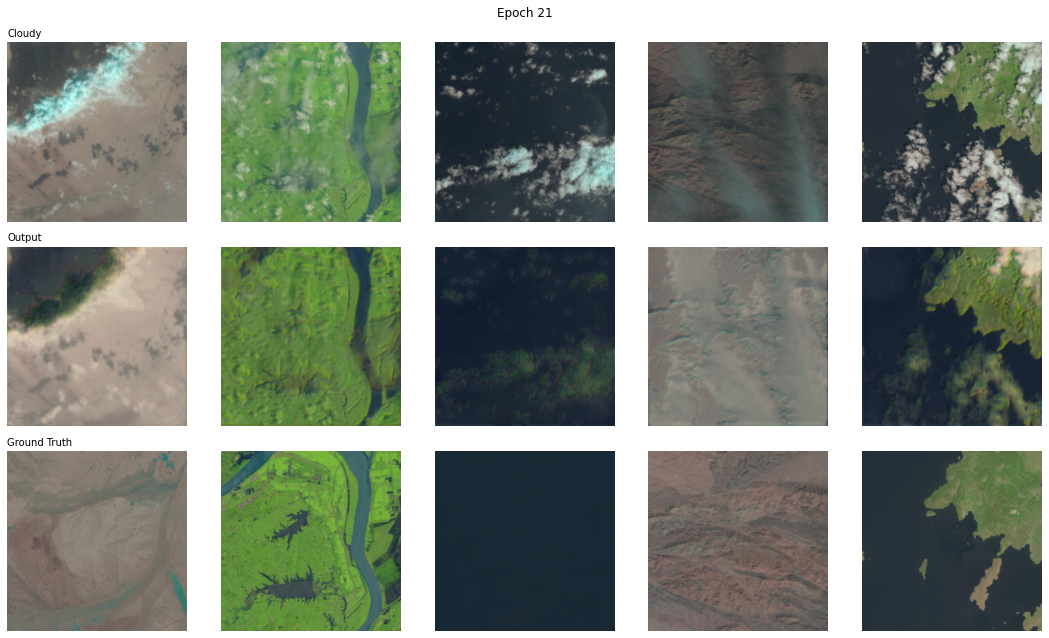

Epoch [21/50] | LR: 1.00e-04 G: 93.09  80.537 | D: 0.45  0.931 | PSNR: 23.29 | SSIM: 0.8007
Epoch [22/50] | LR: 1.00e-04 G: 85.89  56.462 | D: 0.51  0.868 | PSNR: 23.73 | SSIM: 0.7485
Epoch [23/50] | LR: 1.00e-04 G: 94.14  57.065 | D: 0.48  0.787 | PSNR: 24.19 | SSIM: 0.7534
Epoch [24/50] | LR: 1.00e-04 G: 94.93  61.948 | D: 0.47  0.820 | PSNR: 24.09 | SSIM: 0.7937
Epoch [25/50] | LR: 1.00e-04 G: 98.59  71.851 | D: 0.45  0.830 | PSNR: 24.49 | SSIM: 0.7975
Epoch [26/50] | LR: 1.00e-04 G: 101.32  72.247 | D: 0.45  0.882 | PSNR: 23.19 | SSIM: 0.7837
Epoch [27/50] | LR: 1.00e-04 G: 88.00  48.617 | D: 0.52  0.832 | PSNR: 26.15 | SSIM: 0.8061
Epoch [28/50] | LR: 1.00e-04 G: 85.60  68.893 | D: 0.51  0.833 | PSNR: 24.20 | SSIM: 0.7880
Epoch [29/50] | LR: 1.00e-04 G: 82.00  56.919 | D: 0.51  0.830 | PSNR: 24.47 | SSIM: 0.7656
Epoch [30/50] | LR: 1.00e-04 G: 99.07  58.322 | D: 0.45  0.879 | PSNR: 23.82 | SSIM: 0.7940


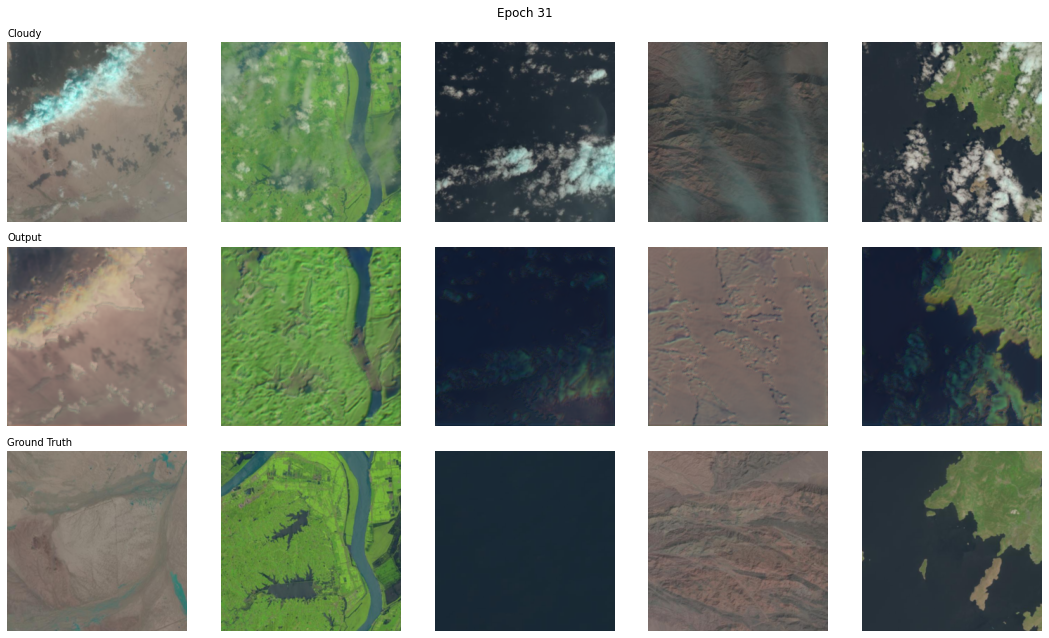

Epoch [31/50] | LR: 1.00e-04 G: 94.92  67.623 | D: 0.51  0.985 | PSNR: 25.78 | SSIM: 0.7864
Epoch [32/50] | LR: 1.00e-04 G: 98.02  54.147 | D: 0.51  0.738 | PSNR: 25.21 | SSIM: 0.7897
Epoch [33/50] | LR: 1.00e-04 G: 85.48  60.839 | D: 0.53  0.889 | PSNR: 26.16 | SSIM: 0.8050
Epoch [34/50] | LR: 1.00e-04 G: 75.85  64.673 | D: 0.56  0.886 | PSNR: 27.27 | SSIM: 0.8111
Epoch [35/50] | LR: 1.00e-04 G: 89.22  76.267 | D: 0.46  0.934 | PSNR: 24.05 | SSIM: 0.8029
Epoch [36/50] | LR: 1.00e-04 G: 95.25  65.612 | D: 0.49  0.738 | PSNR: 22.49 | SSIM: 0.7777
Epoch [37/50] | LR: 1.00e-04 G: 95.31  60.212 | D: 0.47  0.876 | PSNR: 24.90 | SSIM: 0.7876
Epoch [38/50] | LR: 1.00e-04 G: 93.92  83.848 | D: 0.47  1.322 | PSNR: 25.02 | SSIM: 0.7703
Epoch [39/50] | LR: 1.00e-04 G: 86.01  55.514 | D: 0.57  0.859 | PSNR: 25.84 | SSIM: 0.7772
Epoch [40/50] | LR: 1.00e-04 G: 94.81  59.319 | D: 0.47  0.777 | PSNR: 25.26 | SSIM: 0.7988


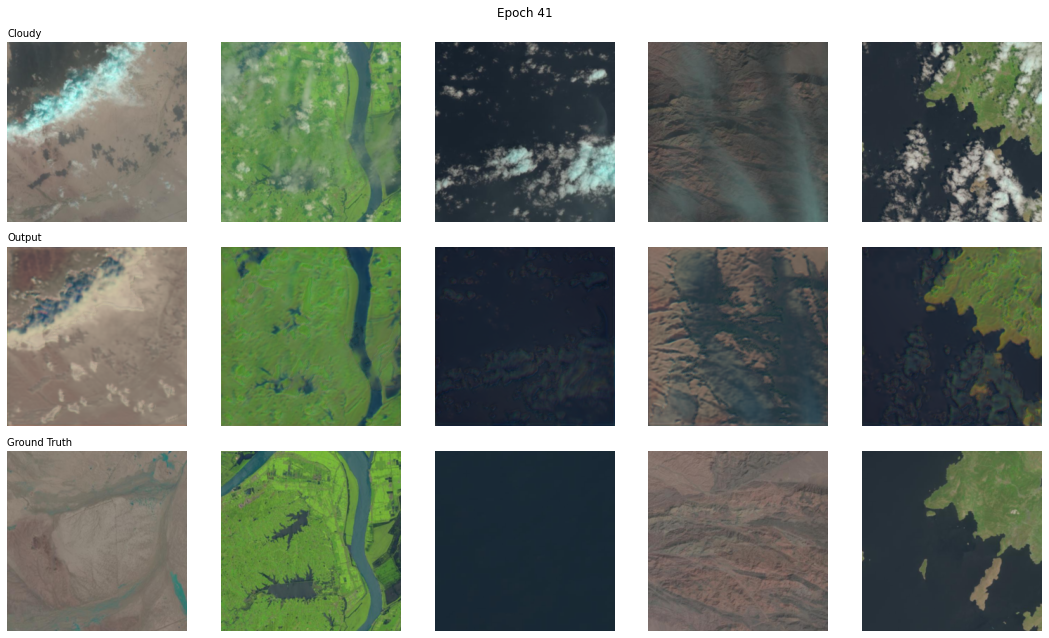

Epoch [41/50] | LR: 1.00e-04 G: 95.09  89.920 | D: 0.47  1.018 | PSNR: 27.61 | SSIM: 0.8220
Epoch [42/50] | LR: 1.00e-04 G: 91.35  76.587 | D: 0.49  0.881 | PSNR: 26.94 | SSIM: 0.8138
Epoch [43/50] | LR: 1.00e-04 G: 84.85  49.188 | D: 0.50  0.898 | PSNR: 26.22 | SSIM: 0.8005
Epoch [44/50] | LR: 1.00e-04 G: 94.58  89.822 | D: 0.47  0.867 | PSNR: 24.37 | SSIM: 0.7513
Epoch [45/50] | LR: 1.00e-04 G: 111.86  81.906 | D: 0.40  0.839 | PSNR: 25.94 | SSIM: 0.8089
Epoch [46/50] | LR: 1.00e-04 G: 123.12  76.581 | D: 0.34  0.810 | PSNR: 24.78 | SSIM: 0.7967
Epoch [47/50] | LR: 1.00e-04 G: 104.40  94.964 | D: 0.47  1.126 | PSNR: 20.88 | SSIM: 0.6990


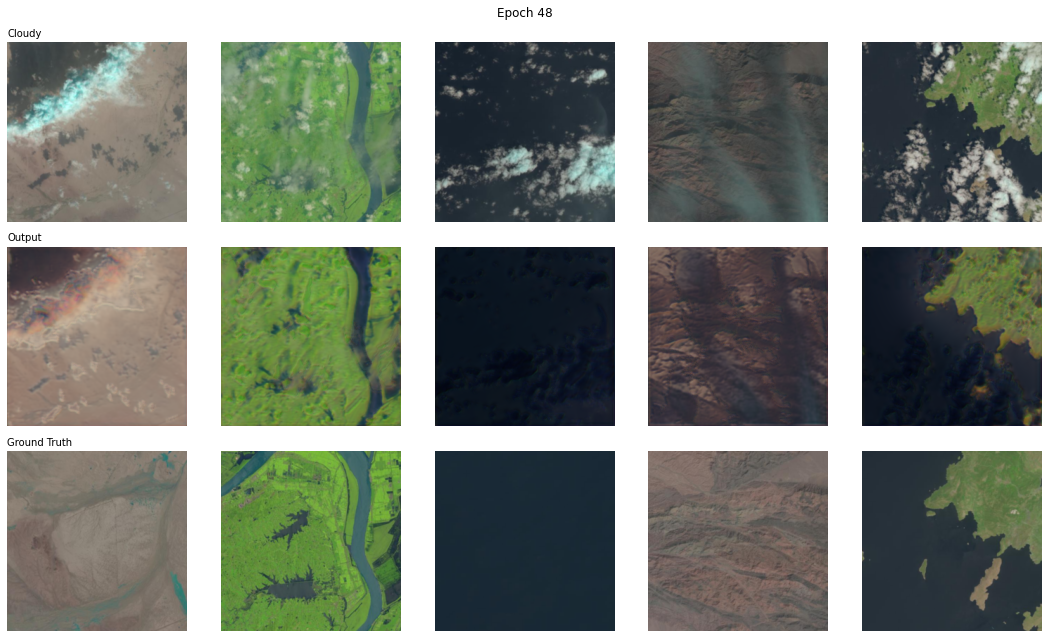

Epoch [48/50] | LR: 1.00e-04 G: 94.06  47.822 | D: 0.50  0.813 | PSNR: 24.49 | SSIM: 0.7660


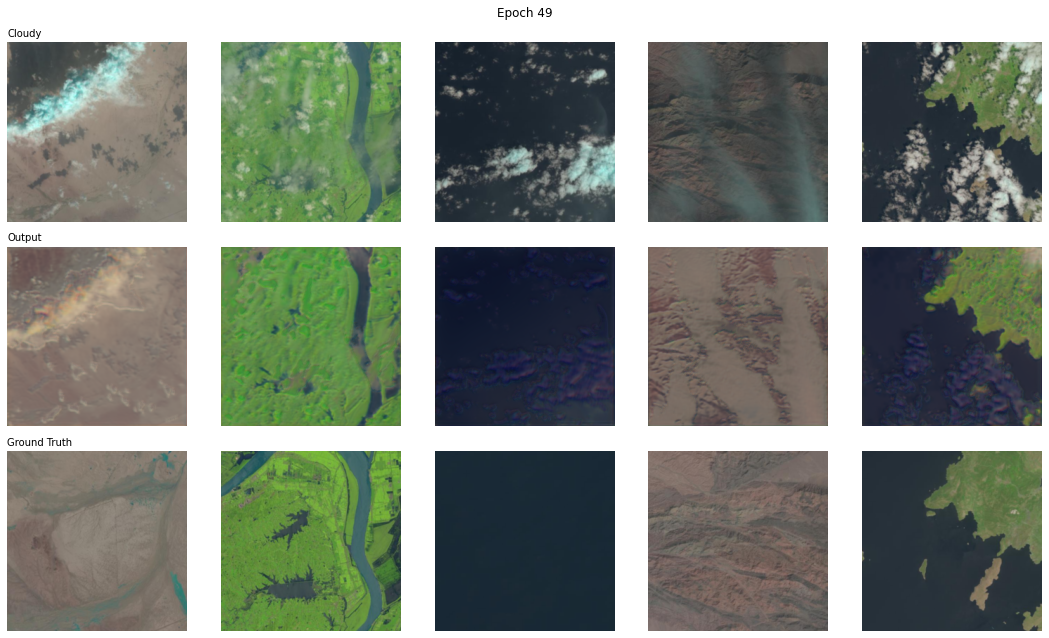

Epoch [49/50] | LR: 1.00e-04 G: 97.35  66.461 | D: 0.48  1.064 | PSNR: 26.28 | SSIM: 0.7980


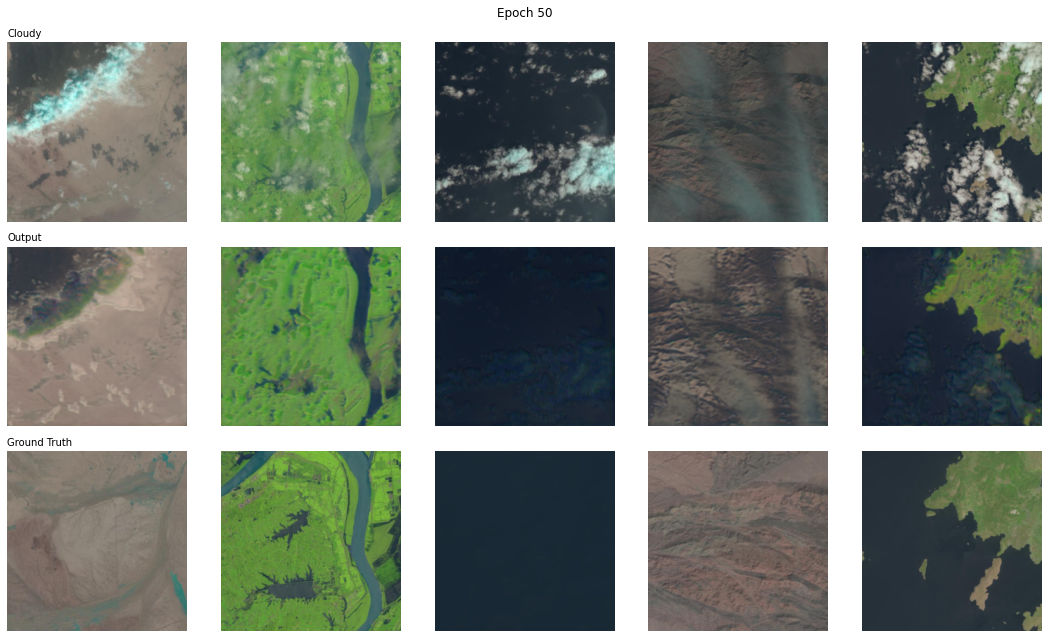

Epoch [50/50] | LR: 1.00e-04 G: 99.99  67.034 | D: 0.51  0.805 | PSNR: 27.54 | SSIM: 0.8210
Bestes Modell bei Epoch 41 mit PSNR 27.61 dB und SSIM 0.8220


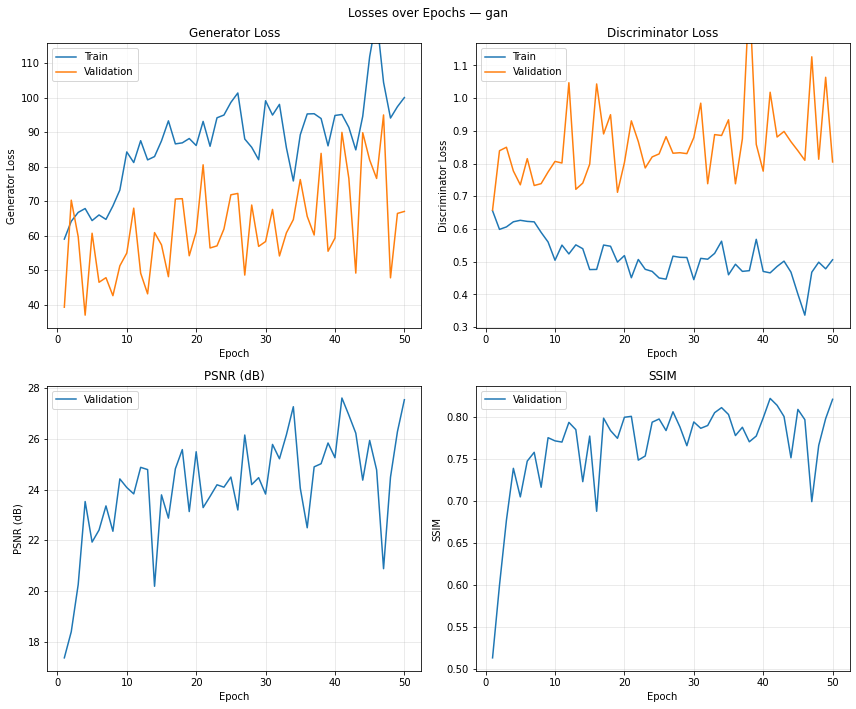

The training took 579.66 seconds with 11.59 seconds per epoch


In [29]:
os.makedirs("checkpoints", exist_ok=True)

save_last_n_samples = 3   # Sample-Bilder der letzten N Epochen speichern
plot_every = 10
start_time = time.time()

for epoch in range(num_epochs):
    generator.train()
    discriminator.train()
    epoch_g, epoch_d = [], []

    for cloudy, label, mask in train_dataloader:
        cloudy = cloudy.to(device)
        label = label.to(device)
        mask = mask.to(device)

        # ---- Discriminator ----
        optimizer_d.zero_grad()
        if use_masks:
            fake = generator(torch.cat((cloudy, mask), dim=1)).detach()
        else: 
            fake = generator(cloudy).detach()
        fake_input = torch.cat((cloudy, fake), dim=1)
        real_input = torch.cat((cloudy, label), dim=1)

        out_real = discriminator(real_input)
        out_fake = discriminator(fake_input)

        # ones_like/zeros_like -> passt für whole-image-D [B,1] UND PatchGAN [B,1,N,N]
        loss_d_real = bce(out_real, torch.ones_like(out_real))
        loss_d_fake = bce(out_fake, torch.zeros_like(out_fake))
        loss_d = (loss_d_real + loss_d_fake) / 2
        loss_d.backward()
        optimizer_d.step()

        # ---- Generator ----
        optimizer_g.zero_grad()
        if use_masks:
            output_gen = generator(torch.cat((cloudy, mask), dim=1))
        else:
            output_gen = generator(cloudy)
        out_disc = discriminator(torch.cat((cloudy, output_gen), dim=1))

        loss_g_adv = bce(out_disc, torch.ones_like(out_disc))
        loss_g_recon = l1(output_gen, label)
        if use_masks:
            loss_g_recon_masked = weighted_l1_loss(output_gen, label, mask, extra=w_extra)
        else:
            loss_g_recon_masked = 0
        loss_g = loss_g_recon + beta * loss_g_adv + w_factor * loss_g_recon_masked
        loss_g.backward()
        optimizer_g.step()

        epoch_g.append(loss_g.item())
        epoch_d.append(loss_d.item())

    train_losses_g.append(sum(epoch_g) / len(epoch_g))
    train_losses_d.append(sum(epoch_d) / len(epoch_d))

    if scheduler_g is not None:
        scheduler_g.step()
    if scheduler_d is not None:
        scheduler_d.step()

    # ---- Validation ----
    generator.eval()
    discriminator.eval()
    gen_val_loss = 0
    disc_val_loss = 0
    psnr_total = 0.0
    ssim_total = 0.0
    n_images = 0

    with torch.no_grad():
        for cloudy, target, mask in val_dataloader:
            cloudy = cloudy.to(device)
            target = target.to(device)
            mask = mask.to(device)

            if use_masks:
                output_gen = generator(torch.cat((cloudy, mask), dim=1))
            else:
                output_gen = generator(cloudy)
            d_real = discriminator(torch.cat((cloudy, target), dim=1))
            d_fake = discriminator(torch.cat((cloudy, output_gen), dim=1))

            disc_val_loss += (
                (bce(d_real, torch.ones_like(d_real))
                 + bce(d_fake, torch.zeros_like(d_fake))) / 2
            ).item()
            gen_val_loss += (
                l1(output_gen, target)
                + beta * bce(d_fake, torch.ones_like(d_fake))
                + w_factor * weighted_l1_loss(output_gen, target, mask, extra=w_extra)
            ).item()

            # PSNR / SSIM pro Bild
            for i in range(output_gen.size(0)):
                out_np = to_img(output_gen[i])
                gt_np = to_img(target[i])
                psnr_total += psnr_fn(gt_np, out_np, data_range=1.0)
                ssim_total += compute_ssim(gt_np, out_np)
                n_images += 1

    val_losses_g.append(gen_val_loss / len(val_dataloader))
    val_losses_d.append(disc_val_loss / len(val_dataloader))
    val_psnrs.append(psnr_total / n_images)
    val_ssims.append(ssim_total / n_images)

    score = val_ssims[-1]
    if  score > best_score:
        torch.save(
            {
                "epoch": epoch,
                "generator": generator.state_dict(),
                "discriminator": discriminator.state_dict(),
            },
            "checkpoints/gan/best.pt",
        )
        best_score = score
        best_psnr = val_psnrs[-1]

    # ---- Sample-Outputs: regelmäßig zeigen, letzte paar Epochen speichern ----
    save_path = None
    if epoch >= num_epochs - save_last_n_samples:
        save_path = f"checkpoints/gan/samples_epoch{epoch + 1}.png"
    if epoch % plot_every == 0 or epoch >= num_epochs - save_last_n_samples:
        plot_samples_gan(
            generator, fixed_batch, device, epoch,
            save_path=save_path, use_masks=use_masks,
        )

    print(
    f"Epoch [{epoch+1}/{num_epochs}] | LR: {optimizer_g.param_groups[0]['lr']:.2e} "
    f"G: {train_losses_g[-1]:.2f}  {val_losses_g[-1]:.3f} | "
    f"D: {train_losses_d[-1]:.2f}  {val_losses_d[-1]:.3f} | "
    f"PSNR: {val_psnrs[-1]:.2f} | SSIM: {val_ssims[-1]:.4f}"
)

print(
    f"Bestes Modell bei Epoch {torch.load('checkpoints/gan/best.pt', map_location=device)['epoch'] + 1} "
    f"mit PSNR {best_psnr:.2f} dB und SSIM {best_score:.4f}"
)
# ----------------------------------------------------------------------
# Nach dem Training: Plots speichern
# ----------------------------------------------------------------------
plot_losses(
    {
        "Generator Loss": (train_losses_g, val_losses_g),
        "Discriminator Loss": (train_losses_d, val_losses_d),
        "PSNR (dB)": (None, val_psnrs),
        "SSIM": (None, val_ssims),
    },
    model_name="gan",
    ncols=2,
    save_path="checkpoints/gan/metrics.png",
)

duration = time.time() - start_time
print(
    f"The training took {duration:.2f} seconds "
    f"with {duration / num_epochs:.2f} seconds per epoch"
)

Bestes Modell aus Epoch 41 geladen.
TEST  PSNR: 28.08 dB | SSIM: 0.8110  (über 148 Bilder)


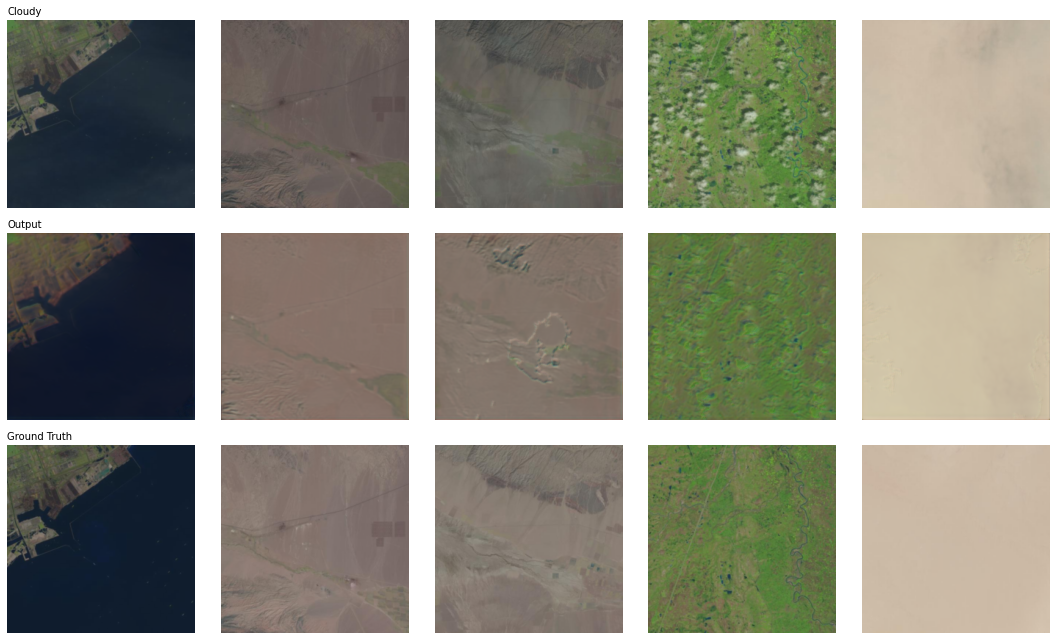

In [ ]:

ckpt = torch.load("checkpoints/gan/best.pt", map_location=device)
generator.load_state_dict(ckpt["generator"])
generator.eval()
print(f"Bestes Modell aus Epoch {ckpt['epoch'] + 1} geladen.")
 
# ---- Metriken über das ganze Test-Set ----
psnr_total, ssim_total, n = 0.0, 0.0, 0
with torch.no_grad():
    for cloudy, target, mask in test_dataloader:
        cloudy, target, mask = cloudy.to(device), target.to(device), mask.to(device)
        output_gen = generator(torch.cat((cloudy, mask), dim=1))
        for i in range(output_gen.size(0)):
            out_np, gt_np = to_img(output_gen[i]), to_img(target[i])
            psnr_total += psnr_fn(gt_np, out_np, data_range=1.0)
            ssim_total += compute_ssim(gt_np, out_np)
            n += 1
 
test_psnr = psnr_total / n
test_ssim = ssim_total / n
print(f"TEST  PSNR: {test_psnr:.2f} dB | SSIM: {test_ssim:.4f}  (über {n} Bilder)")
 

 
plot_test_samples(
    generator, test_dataloader, device,
    n_show=5, save_path="checkpoints/gan/test_samples.png", use_masks=use_masks
)